<h1 style="color:magenta;">NSL - Exercises 01 </h1>

### 5/3/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 1
We want to test the Pseudo-Random Number generator downloaded from the NSL Ariel web site. 
1. We estimated $\langle r \rangle = \int_0^1 r dr = 1/2$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle r \rangle$) with a large number of *throws* $M=10^4$ as a function of the number of blocks, $N=100$ (blocking method).

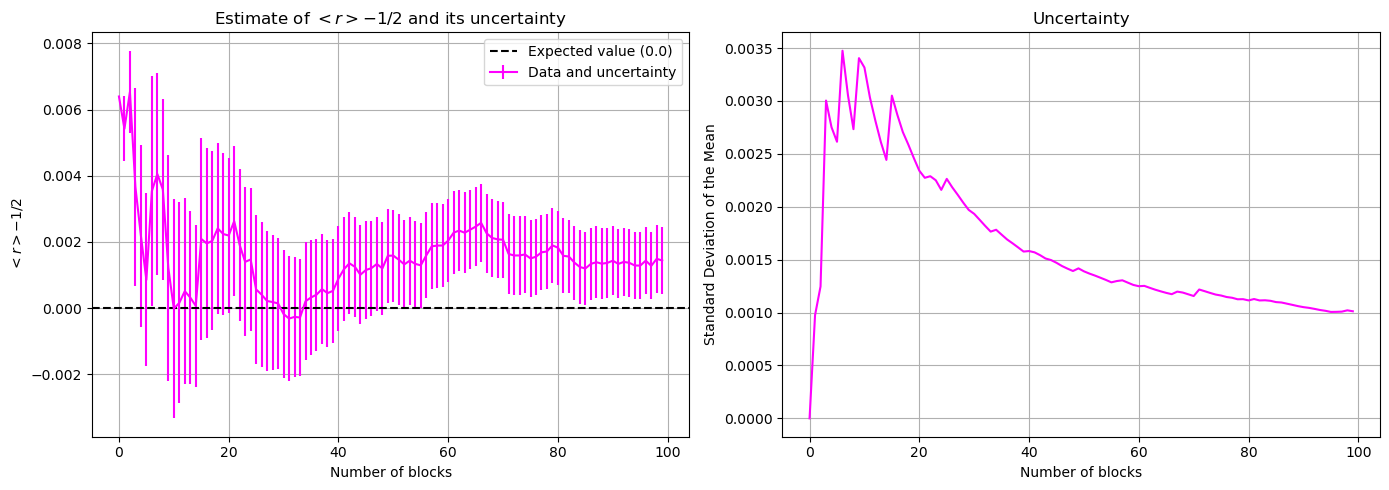

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data = np.loadtxt("Exercise_1/output_ave.dat")

#<r> with error bars
x = data[:, 0]    #Number of blocks
y = data[:, 1]    #<r>-1/2
err = data[:, 2]  #Standard deviation of the mean

ax1.errorbar(x, y, yerr=err, label="Data and uncertainty", color='magenta')
ax1.set_xlabel("Number of blocks")
ax1.set_ylabel("$<r> - 1/2$")
ax1.set_title("Estimate of $<r> - 1/2$ and its uncertainty")
ax1.axhline(y=0.0, color='black', linestyle='--', label='Expected value (0.0)')
ax1.legend()
ax1.grid()

#sigma
x_var = data[:, 0] #throws
y_var = data[:, 2] #std


ax2.plot(x_var, y_var, color='magenta')
ax2.set_xlabel("Number of blocks")
ax2.set_ylabel("Standard Deviation of the Mean")
ax2.set_title("Uncertainty")
ax2.grid()


plt.tight_layout()
plt.show()

2. Estimate of $\sigma^2 = \int _0^1 \left(r-1/2 \right)^2 \, dr = 1/12 $ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle (r-1/2)^2 \rangle$) with a large number of *throws* $M = 10^4$) as a function of the number of blocks, $N$

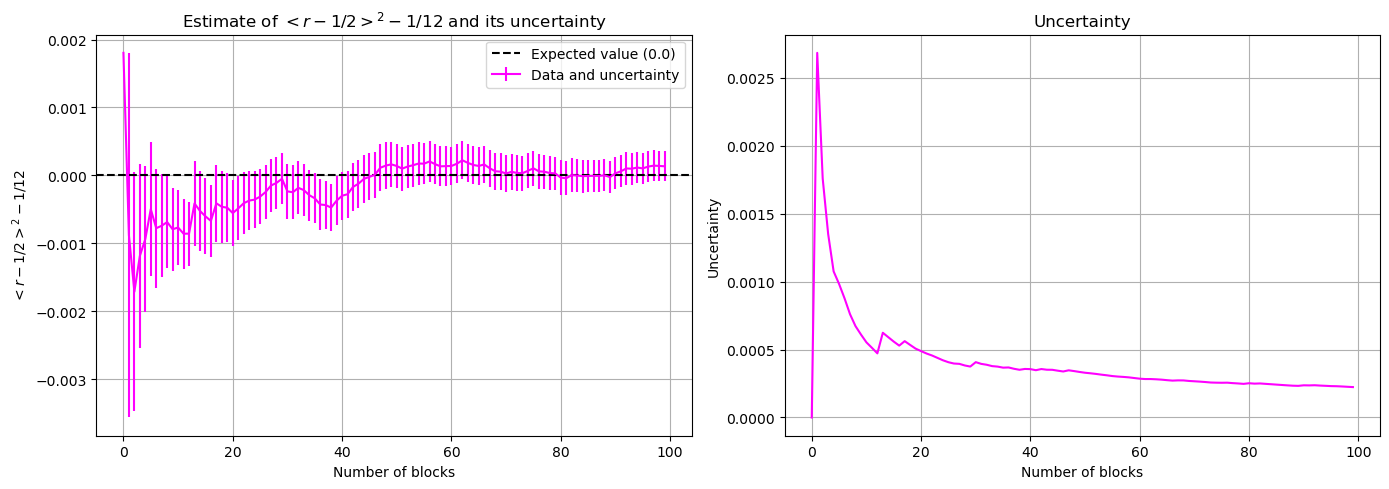

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data = np.loadtxt("Exercise_1/output_sigma.dat")

#<r> with error bars
x = data[:, 0]    #Number of blocks
y = data[:, 1]    #sigma^2 - 1/12
err = data[:, 2]  #uncertainty

ax1.errorbar(x, y, yerr=err, label="Data and uncertainty", color='magenta')
ax1.set_xlabel("Number of blocks")
ax1.set_ylabel("$<r-1/2>^2 - 1/12$")
ax1.set_title("Estimate of $<r-1/2>^2 - 1/12$ and its uncertainty")
ax1.axhline(y=0.0, color='black', linestyle='--', label='Expected value (0.0)')
ax1.legend()
ax1.grid()

#sigma
x_var = data[:, 0] #throws
y_var = data[:, 2] #std


ax2.plot(x_var, y_var, color='magenta')
ax2.set_xlabel("Number of blocks")
ax2.set_ylabel("Uncertainty")
ax2.set_title("Uncertainty")
ax2.grid()


plt.tight_layout()
plt.show()

In both simulations the uncertainties are in good agreement with the $1/\sqrt{N}$ scaling, as we expect from the Central Limit Theorem

3. It was hypothesized that the values of $r$ are drawn from a uniform distribution. In statistics, however, it is strictly impossible to prove that random events originate from a specific distribution. Furthermore, this hypothesis is technically false, as pseudo-random numbers are generated by deterministic algorithms. Nevertheless, we can estimate the probability that the values of $r$ are not drawn from a uniform distribution. If this probability is sufficiently low, we can reasonably reject the null hypothesis. The interval $[0, 1]$ was divided into $M=10^2$ identical sub-intervals. For each block of $n=10^4$ pseudo-random numbers, the $\chi^2_j$ statistic was calculated by comparing the number of observed events $n_i$ in each sub-interval with the expected value $E[n_i] = n/M=100$ (since a uniform distribution predicts equal frequencies). The $\chi^2$ statistic was computed as:$$\chi^2 = \sum_{i=1}^{M} \frac{(n_i - n/M)^2}{n/M}$$This process was repeated for 100 consecutive blocks of $n$ numbers, yielding 100 values of $\chi^2$. Given that the expected variance is $n/M$ for each bin, we expect $\chi^2 \simeq M=100$ if the numbers are indeed uniformly distributed. To evaluate the quality of the pseudo-random generator, the histogram of the obtained $\chi^2$ values was compared with the theoretical chi-squared distribution (with $M-1$ degrees of freedom). Values of $\chi^2$ significantly higher than $100$ would suggest a deviation from uniformity.

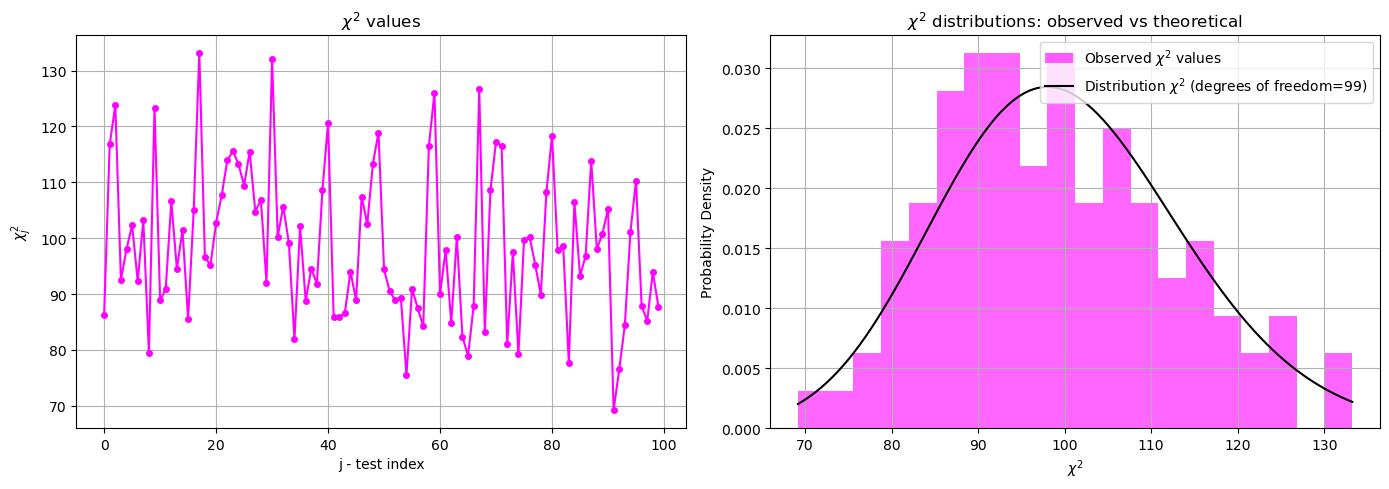

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

data = np.loadtxt("Exercise_1/output_chi2.dat")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#chi^2
x = data[:, 0]   # index j 
y = data[:, 1]   # chi^2_j

ax1.plot(x, y, marker='o', color='magenta', markersize=4)
ax1.set_xlabel("j - test index")
ax1.set_ylabel("$\chi_j^2$")
ax1.set_title("$\chi^2$ values")
ax1.grid()

#Histogram vs th. distribution
M = 100  # dof
ax2.hist(y, bins=20, density=True, alpha=0.6, color='magenta', label='Observed $\chi^2$ values')

x_th = np.linspace(min(y), max(y), 100-1)
ax2.plot(x_th, chi2.pdf(x_th, df=M), 'black', label=r'Distribution $\chi^2$ (degrees of freedom=99)')

ax2.set_xlabel(r'$\chi^2$')
ax2.set_ylabel('PDF')
ax2.set_title('$\chi^2$ distributions: observed vs theoretical')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

We observe that the histogram matches the theoretical $\chi^2$ distribution ($dof=99$) with good agreement. Therefore, we can accept the uniformity hypothesis.

## Ex 2

The purpose of this exercise is to verify the Central Limit Theorem, which states that the sum (or the mean) of a large number of independent and identically distributed random variables tends toward a Gaussian distribution, regardless of the shape of the original distribution. This theorem, however, does not apply to distributions with infinite variance, such as the Cauchy-Lorentz distribution.

The methods Exponential(double lambda) and Lorentz(double mu, double Gamma) were added to the random.cpp file. These methods generate numbers distributed according to an exponential and a Cauchy-Lorentz distribution, respectively, using the inverse cumulative distribution function method. This technique is based on the principle that if $u$ is a uniform random variable in $[0, 1]$ and $F(x)$ is the cumulative distribution function (CDF) of a variable $X$, then the variable $x = F^{-1}(u)$ will follow the desired distribution.
- For the exponential distribution $p(x) = \lambda e^{-\lambda x}$, with $x \in [0, +\infty)$, we obtain:$$x = -\frac{1}{\lambda} \ln(1-u)$$
- For the Cauchy-Lorentz distribution $p(x) = \frac{1}{\pi} \frac{\Gamma}{(x-\mu)^2 + \Gamma^2}$, with $x \in (-\infty, +\infty)$, we have:$$x = \Gamma \tan\left[\pi \left(u - \frac{1}{2}\right)\right] + \mu$$

I performed $10^4$ realizations of $S_N = \frac{1}{N} \sum_{i=1}^{N} x_i$, where $x_i$ is a random variable sampled by throwing a standard, exponential ($\lambda=1$), and Lorentzian ($\mu=0, \Gamma=1$) dice, for $N=1, 2, 10, 100$.

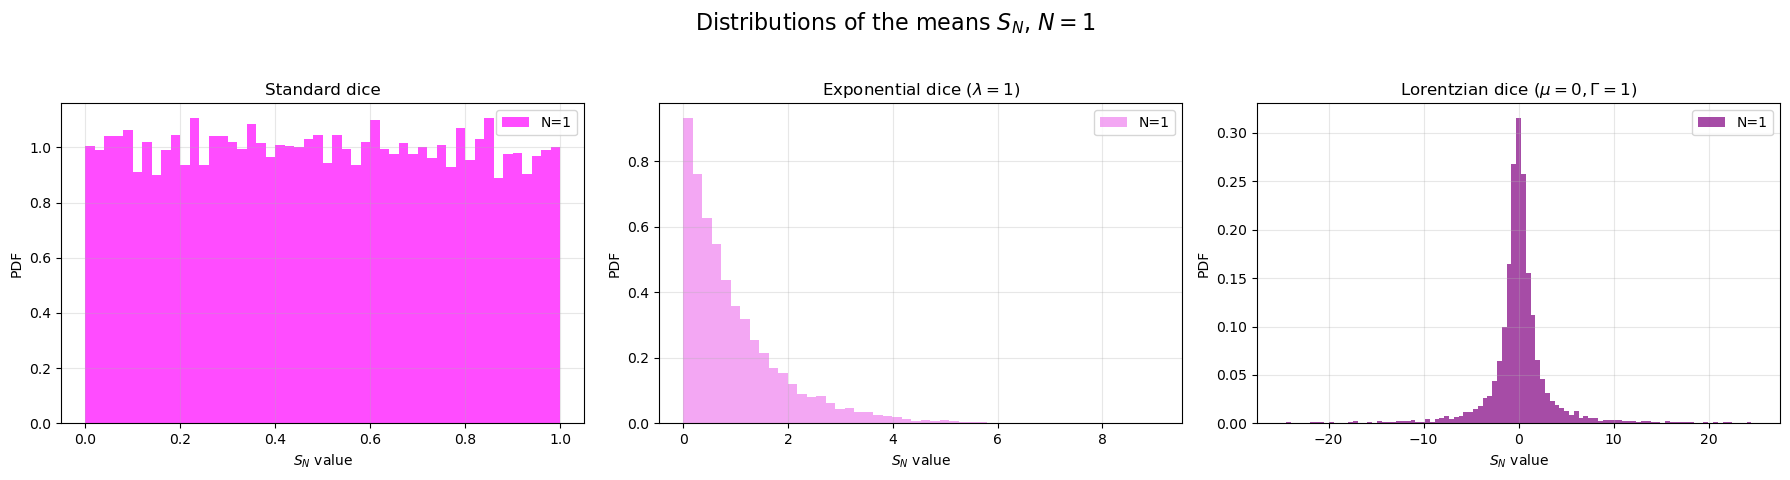

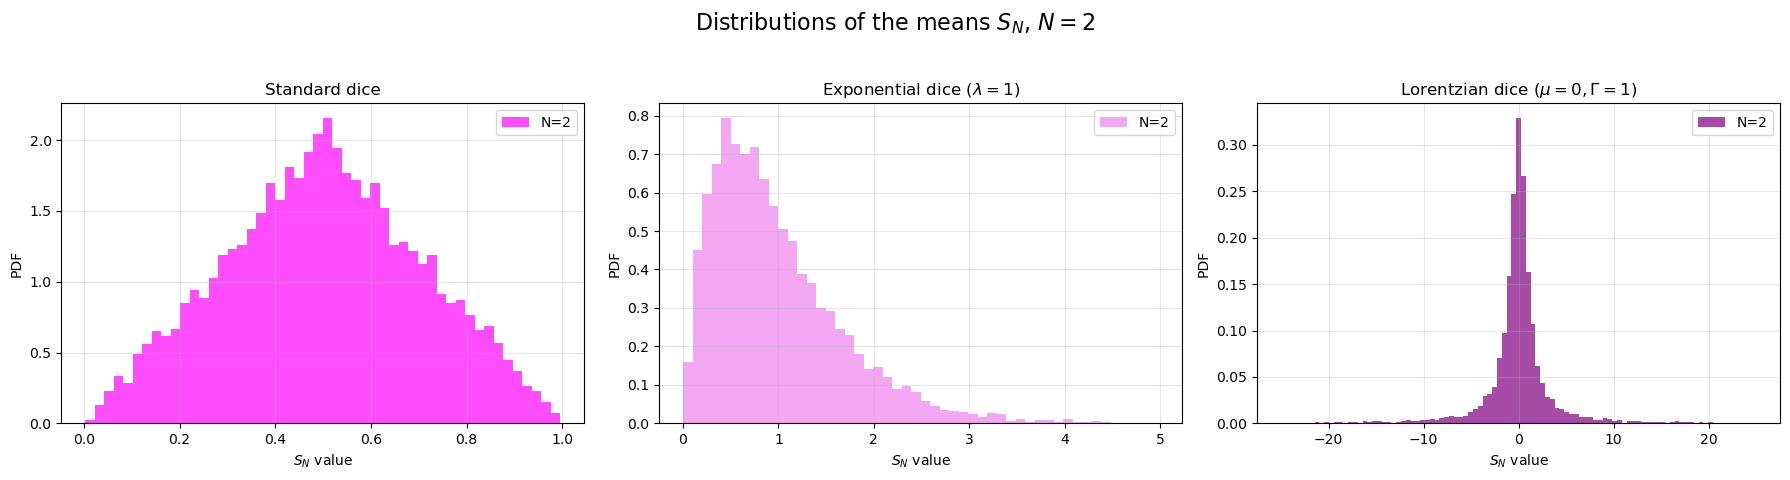

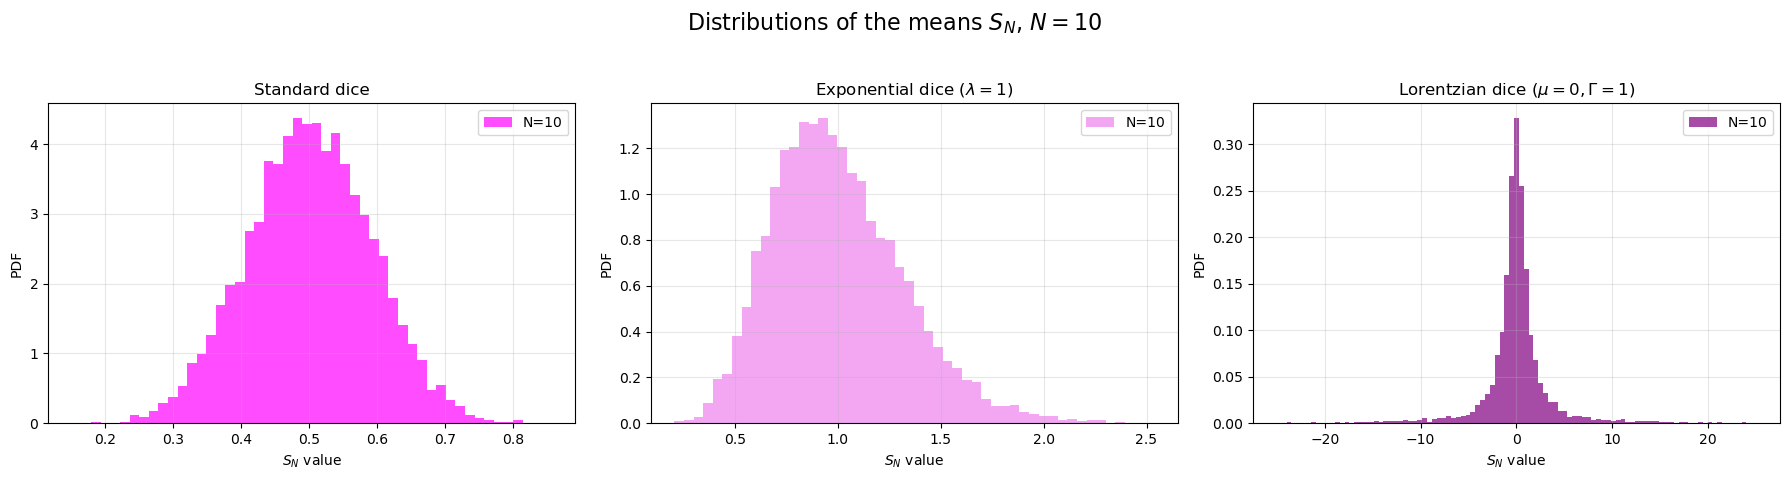

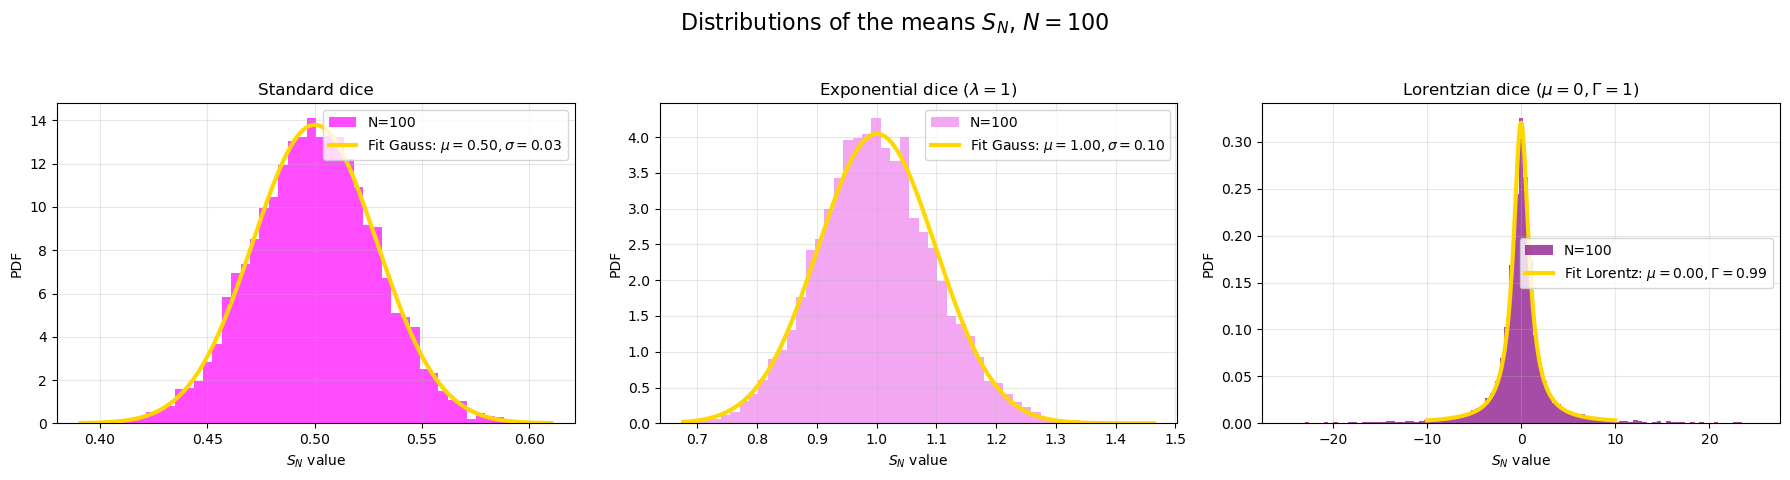

FIT RESULTS FOR N=100 (10^4 realizations):
Standard dice [μ, σ]:    0.5000 ± 0.0003, 0.0289
Exponential dice [μ, σ]:    1.0005 ± 0.0010, 0.0986
Lorentzian dice [μ, Γ]:    0.0020 ± 0.0099, 0.9917


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

# Each file has 10 000 rows and 4 columns (N=1, N=2, N=10, N=100)
data_uni = np.loadtxt("Exercise_2/out_uni.dat")
data_exp = np.loadtxt("Exercise_2/out_exp.dat")
data_lor = np.loadtxt("Exercise_2/out_lor.dat")

datasets = [data_uni, data_exp, data_lor]
titles = ["Standard dice", "Exponential dice ($\lambda=1$)", "Lorentzian dice ($\mu=0, \Gamma=1$)"]
colors = ['magenta', 'violet', 'purple']
N_values = [1, 2, 10, 100]

# Iterate on the 4 values on N (columns of the files)
for i, N in enumerate(N_values):
    # fig 1x3 for each N 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Distributions of the means $S_N$, $N={N}$", fontsize=16)

    for j in range(3):
        # Type of dice
        current_data = datasets[j][:, i]

        # Defining bins for each dice (problems with Lorentzian dice, see below) 
        if j == 2: # Lorentz: limiting the range otherwise I won't see the expected trend (long tails)
            bins = np.linspace(-25, 25, 100)
        else:
            bins = 50

        axes[j].hist(current_data, bins=bins, density=True, alpha=0.7, color=colors[j], label=f'N={N}')
        axes[j].set_title(titles[j])
        axes[j].set_xlabel("$S_N$ value")
        axes[j].set_ylabel("PDF")
        axes[j].grid(True, alpha=0.3)

        # Fit f N=100
        if N == 100:
            x = np.linspace(min(current_data), max(current_data), 200)
            
            if j < 2: # Normal fit for standard and exponential dices
                mu, sigma = norm.fit(current_data)
                y = norm.pdf(x, mu, sigma)
                axes[j].plot(x, y, color='gold', lw=3, label=f'Fit Gauss: $\mu={mu:.2f}, \sigma={sigma:.2f}$')
                
                # Saving parameters 
                if j == 0: std_params = (mu, sigma)
                if j == 1: exp_params = (mu, sigma)
                
            else: # Cauchy fit for lorentian dice 
                x_lor = np.linspace(-10, 10, 200)
                mu_l, gamma_l = cauchy.fit(current_data)
                y_lor = cauchy.pdf(x_lor, loc=mu_l, scale=gamma_l)
                axes[j].plot(x_lor, y_lor, color='gold', lw=3, label=f'Fit Lorentz: $\mu={mu_l:.2f}, \Gamma={gamma_l:.2f}$')
                lor_params = (mu_l, gamma_l)
        
        axes[j].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- FINAL PARAMETERS (N=100) ---
print(f"FIT RESULTS FOR N=100 (10^4 realizations):")
print(f"Standard dice [μ, σ]:    {std_params[0]:.4f} ± {std_params[1]/np.sqrt(10000):.4f}, {std_params[1]:.4f}")
print(f"Exponential dice [μ, σ]:    {exp_params[0]:.4f} ± {exp_params[1]/np.sqrt(10000):.4f}, {exp_params[1]:.4f}")
print(f"Lorentzian dice [μ, Γ]:    {lor_params[0]:.4f} ± {lor_params[1]/np.sqrt(10000):.4f}, {lor_params[1]:.4f}")



For $N=100$, the histograms of the standard and exponential dice are well represented by a Normal fit.
The histogram of the Lorentzian die is well represented by a Cauchy-Lorentz distribution: this PDF has infinite variance, therefore violating one of the fundamental hypotheses of the CLT.

## Ex. 3
A simulation of Buffon's needle experiment was implemented, in which a needle of length $L$ is randomly dropped onto a plane ruled with parallel lines at a distance $d$ (where $d \gtrsim L$). The theoretical probability that the needle intersects a line is $P = \frac{2L}{\pi d}$. For each throw, the distance $x \in (0; d/2)$ of the needle's center from the nearest line and the angle $\theta \in [0; 2 \pi]$ relative to the horizontal were randomly generated. The number of intersections was then counted based on the condition $x < \frac{L}{2} | \sin \theta |$. After $N_{thr}=10^5$ throws, with $N_{hit}$ observed intersections, $\pi$ was estimated as:$$\pi = \frac{2L \cdot N_{thr}}{d \cdot N_{hit}}$$The simulation was repeated for $N_{blk}=100$ independent blocks (each consisting of $N_{thr}$ throws). The uncertainty in the estimate of $\pi$ was evaluated using the standard deviation of the block estimates, divided by $\sqrt{N_{blk}}$ (standard error of the mean).

The trend of $\pi$ and its uncertainty was plotted as a function of the number of blocks $N_{blk}$, showing convergence toward the true value of $\pi$. The error decreases as $1/\sqrt{N_{blk}}$, which is consistent with Monte Carlo statistics

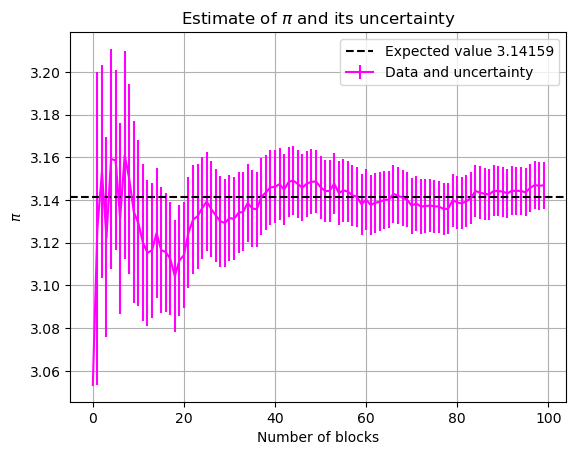

In [16]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt("Exercise_3/output_pi.dat")

#pi with error bars
x = data[:, 0]    #Number of blocks
y = data[:, 1]    #pi
err = data[:, 2]  #Standard deviation of the mean

plt.errorbar(x, y, yerr=err, label="Data and uncertainty", color='magenta')
plt.xlabel("Number of blocks")
plt.ylabel("$\pi$")
plt.title("Estimate of $\pi$ and its uncertainty")
plt.axhline(y=np.pi, color='black', linestyle='--', label='Expected value 3.14159')
plt.legend()
plt.grid()

plt.show()